# Legal Text Classification - Exploratory Data Analysis

This notebook explores the **ECtHR (European Court of Human Rights)** dataset 
from the [LexGLUE benchmark](https://huggingface.co/datasets/coastalcph/lex_glue).

## Objectives
- Understand the dataset structure and splits
- Analyze class distribution and identify imbalance
- Examine text length to inform tokenization decisions
- Inspect sample texts per class

## Dataset
- **Source:** LexGLUE (`ecthr_a` task)
- **Task:** Predict which articles of the European Convention on Human Rights 
  were violated based on case facts
- **Model to be fine-tuned:** DistilBERT (`distilbert-base-uncased`)

### Import packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset # HuggingFace datasets library's main function
from collections import Counter   # built-in Python utility that counts occurrences of items in a list

# Display settings
pd.set_option('display.max_colwidth', 100) # increase display width in a column to 100 characters
sns.set_theme(style = 'whitegrid')

print("All imports successful!")

All imports successful!


## 1. Load Dataset

In [2]:
dataset = load_dataset("lex_glue", "ecthr_a")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
})


## 2. Dataset Structure

In [3]:
# Look at the train-test-validation split
train_data = dataset['train']
test_data  = dataset['test']
val_data   = dataset['validation']

# Print basic information
print(f'Train data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')
print(f'Validation data size: {len(val_data)}')
print(f'\nNumber of features: {train_data.features}')

Train data size: 9000
Test data size: 1000
Validation data size: 1000

Number of features: {'text': List(Value('string')), 'labels': List(ClassLabel(names=['2', '3', '5', '6', '8', '9', '10', '11', '14', 'P1-1']))}


## 3. Key Findings from Dataset Structure

### Text Format
- Each case is stored as a **list of paragraphs** (not a single string)
- Paragraphs will need to be **joined into one string** before tokenization

### Label Format
- This is a **multi-label classification** task
- Each case can violate **multiple ECHR articles** simultaneously
- There are **10 possible article labels**

### ECHR Article Labels
| Article | Right Protected |
|---------|----------------|
| 2       | Right to life |
| 3       | Prohibition of torture |
| 5       | Right to liberty and security |
| 6       | Right to a fair trial |
| 8       | Right to respect for private and family life |
| 9       | Freedom of thought, conscience and religion |
| 10      | Freedom of expression |
| 11      | Freedom of assembly and association |
| 14      | Prohibition of discrimination |
| P1-1    | Protection of property |

### Implications for Modeling

#### Loss Function: Binary Cross Entropy (BCE)
- Multi-label classification is **not** the same as multi-class classification
- We are making **10 independent binary decisions** per case (violated or not)
- Each article is its own yes/no question — they do **not** compete with each other
- Therefore BCE is correct — it evaluates each label independently
- Cross Entropy would be **wrong** here because it forces all probabilities to sum to 1,
  implying only one label can be correct

#### Tokenization
- Text paragraphs must be **joined and truncated** to fit DistilBERT's 512 token limit

#### Evaluation Metrics
- Standard accuracy is misleading for multi-label tasks
- Better metrics: **F1 score (micro/macro)**, **precision**, **recall** per label

## 4. Sample Inspection

In [4]:
# look at first training example
example = train_data[0]

print(f'Number of paragraphs: {len(example['text'])}')
print(f'\nFirst paragraph: \n{example['text'][0]}')
print(f'\nLast paragraph: \n{example['text'][-1]}')
print(f'\nLabel index: {example['labels']}') # i.e. label = '8'

Number of paragraphs: 83

First paragraph: 
11.  At the beginning of the events relevant to the application, K. had a daughter, P., and a son, M., born in 1986 and 1988 respectively. P.’s father is X and M.’s father is V. From March to May 1989 K. was voluntarily hospitalised for about three months, having been diagnosed as suffering from schizophrenia. From August to November 1989 and from December 1989 to March 1990, she was again hospitalised for periods of about three months on account of this illness. In 1991 she was hospitalised for less than a week, diagnosed as suffering from an atypical and undefinable psychosis. It appears that social welfare and health authorities have been in contact with the family since 1989.

Last paragraph: 
93.  J. and M.’s foster mother died in May 2001.

Label index: [4]


## 5. Text Length Analysis

In [5]:
# Join paragraphs and calculate word counts
def get_word_count(example):
    joined = " ".join(example['text']) # join strings using a single space character
    return len(joined.split())         # splits a string into words using a default whitespace

# Calculate word counts for train split
word_counts = [get_word_count(train_data[i]) for i in range(len(train_data))]

# Summary statistics
wc = pd.Series(word_counts) # convert the python list to pandas series
print("Word Count Statistics (Train):")
print(wc.describe())        # gives a statistical summary
print(f"\nCases exceeding 512 words: {(wc > 512).sum()}")
print(f"Cases exceeding 512 words: {((wc > 512).sum())/len(wc)*100:.1f}%")

Word Count Statistics (Train):
count     9000.000000
mean      1619.237111
std       1995.117127
min         69.000000
25%        480.750000
50%        984.000000
75%       2002.250000
max      35416.000000
dtype: float64

Cases exceeding 512 words: 6564
Cases exceeding 512 words: 72.9%


## 6. Text Length Distribution

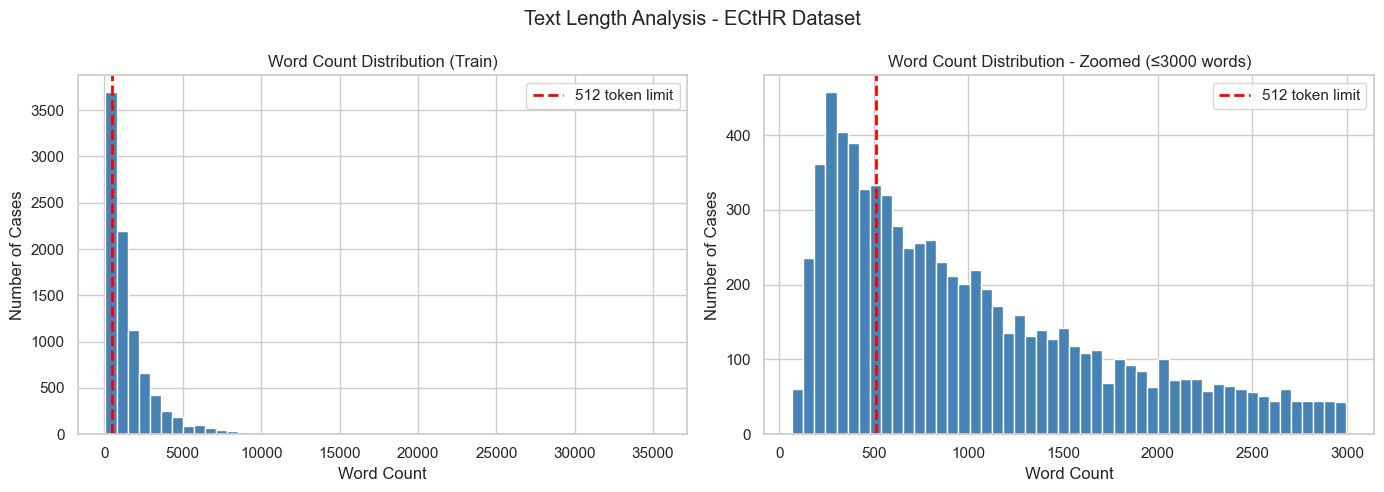

Showing 7749/9000 cases in zoomed plot


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Full distribution
axes[0].hist(word_counts, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=512, color='red', linestyle='--', linewidth=2, label='512 token limit')
axes[0].set_title('Word Count Distribution (Train)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Cases')
axes[0].legend()

# Plot 2 - Zoomed in under 3000 words (cleaner view)
filtered = [w for w in word_counts if w <= 3000]
axes[1].hist(filtered, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=512, color='red', linestyle='--', linewidth=2, label='512 token limit')
axes[1].set_title('Word Count Distribution - Zoomed (≤3000 words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Cases')
axes[1].legend()

plt.suptitle('Text Length Analysis - ECtHR Dataset')  # title for whole figure
plt.tight_layout() # adjusts spacing between subplots
plt.show()

print(f"Showing {len(filtered)}/{len(word_counts)} cases in zoomed plot")

## 7. Key Findings from Text Length Analysis

### Statistics
| Metric | Value |
|--------|-------|
| Mean word count | 1,619 words |
| Median word count | 984 words |
| Minimum word count | 69 words |
| Maximum word count | 35,416 words |
| Cases exceeding 512 words | 6,564 / 9,000 (72.9%) |

### Observations
- The distribution is **highly right-skewed** - most cases cluster under 3,000 words
  but a long tail extends to 35,416 words
- The std. deviation (1,995) is larger than the mean (1,619), confirming
  **high variability** in case lengths
- **72.9% of training cases will be truncated** by DistilBERT's 512 token limit

### Implications
- Simple truncation to 512 tokens is the chosen strategy for this project
- This is acceptable because court documents typically state key facts
  in early paragraphs
- However, truncation is a **known limitation** - for future improvement,
  models like Longformer (supports up to 4,096 tokens) could be explored
  to capture the full document context

### Future Improvement
- Experiment with **Longformer** for longer sequence support
- Explore **chunking strategies** - classify each 512-token chunk
  separately and aggregate predictions